In [78]:
import os

from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
tavily =  TavilySearchResults(max_results=5)

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

tavily = TavilySearchResults(api_key=TAVILY_API_KEY)
q=" what is the capital of France?"
results = tavily.invoke({"query": q})

print(results)

[{'title': 'Paris, France | Geography and Cartography | Research Starters', 'url': 'https://www.ebsco.com/research-starters/geography-and-cartography/paris-france', 'content': 'Browse Subject Areas\n\n# Paris, France\n\nParis, the capital of France, is renowned globally for its iconic landmarks such as the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral. This vibrant city, located along the Seine River in the Île de France region, is divided into 20 arrondissements, each with its unique character and cultural significance. Paris is not only a historical epicenter but also a major hub for international fashion, attracting millions of tourists each year—over 40 million in 2022—who come to experience its art, cuisine, and diverse attractions. [...] ## Paris, France\n\nParis is the capital of France and is known throughout the world as the home of such attractions as the Louvre Museum, the Eiffel Tower, and Notre-Dame Cathedral. It is also internationally recognized as a center f

In [79]:
import os
from dotenv import load_dotenv

# Load .env file
load_dotenv()

# Access keys
openrouter_key = os.getenv("OPENROUTER_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")


In [80]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,List,Dict,Any
from langchain_openai import ChatOpenAI
from langchain_community.vectorstores import FAISS
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
import operator
from dotenv import load_dotenv
import os
from tavily import TavilyClient

load_dotenv()

True

In [81]:

# Create LLM
llm = ChatOpenAI(
    model="openrouter/auto",
    #api_key=openrouter_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7
)

# Test
response = llm.invoke("Explain batch normalization in simple terms")
print(response.content)

 Batch normalization is a technique used in deep learning to make the training of neural networks more stable and efficient. It helps to normalize the input data of each layer, making it have zero mean and unit variance. This normalization process reduces the internal covariate shift, which is the change in the distribution of the input data during the training process.

In simpler terms, imagine you are baking a cake. The ingredients you use (input data) can have different quantities of sugar, flour, or eggs. This can affect the final outcome of the cake (the neural network's output). Batch normalization is like adding a special ingredient (the normalization process) that adjusts the quantities of the other ingredients (input data) to ensure a consistent final product (stable and efficient neural network training).


In [82]:
PATH=r"C:\Projects\rag_project\Methodology_Paper.pdf"

In [ ]:
import requests
from dotenv import load_dotenv

load_dotenv()

JINA_API_KEY = os.getenv("JINA_API_KEY")
def get_embeddings_batch(texts):
    url = "https://api.jina.ai/v1/embeddings"

    headers = {
        "Authorization": f"Bearer {JINA_API_KEY}",  
        "Content-Type": "application/json"
    }

    data = {
        "input": texts,  # list of texts
        "model": "jina-embeddings-v2-base-en"
    }

    response = requests.post(url, headers=headers, json=data)



    return [item["embedding"] for item in response.json()["data"]]


from langchain_core.embeddings import Embeddings
class JinaEmbeddings(Embeddings):
    def embed_documents(self, texts):
        return get_embeddings_batch(texts)

    def embed_query(self, text):
        return get_embeddings_batch([text])[0]



embedding = JinaEmbeddings()
loader = PyPDFLoader(PATH)   # PATH = "file.pdf"
documents = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=150
)

chunks = splitter.split_documents(documents)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")
vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})



--- Doc 0 ---

PDSCC 7.343 369.09 22.46 18,882 0.986 1.251 2.979
UCM 7.683 3411.33 12.80 37,712 0.772 4.815 2.950
ICM 7.618 1812.00 15.55 35,816 0.804 8.251 2.970
CLAHS 7.420 1481.68 16.42 41,090 0.799 2.937 3.049
HE 5.982 3534.60 12.62 40,995 0.654 6.486 2.780
DIRS-CLAHS 7.673 509.54 21.06 40,962 0.949 9.982 3.01

--- Doc 1 ---

and detailed in subsequent sections.
3. Motivation
The studies conducted by Iqbal et al. [10,11] and Abdul Ghani
and Mat Isa[29] indicate a limitation in the stretching process, espe-
cially when the original histogram of the image is already stretched
out to the entire dynamic range or almost the e

--- Doc 2 ---

[4] J.F. Anthoni, Water and Light in Underwater Photography, 2012, http://www.
seafriends.org.nz/phgraph/water.htm (accessed on September 2012).
[5] C. Ancuti, C.O. Ancuti, T. Haber, P. Bekaert, Enhancing underwater images and
video by fusion, in: IEEE International Conference on Computer Vision and

--- Doc 3 ---

A.S. Abdul Ghani, N.A. Mat Isa / 

In [123]:
class State(TypedDict):
    question: str
    verdict: str
    docs : list[Document]
    
    good_docs: List[Document]
    reason: str
    web_query:str
    web_docs: List[Document]
    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    answer: str

    top_docs: List[Document]


In [124]:
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [125]:
from typing import List
import numpy as np

def cosine_sim(a, b):
    a = np.array(a)
    b = np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def rerank_documents(state : State) -> State:
    """
    Reranks retrieved documents using embedding similarity.
    """
    print("Reranking documents...")
    # embed query once
    q_vec = embedding.embed_query(state["question"])

    scored_docs = []

    for doc in state["docs"]:
        doc_text = doc.page_content

        # embed doc
        d_vec = embedding.embed_query(doc_text)

        score = cosine_sim(q_vec, d_vec)
        scored_docs.append((doc, score))

    # sort by score (descending)
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    # return top-k docs only
    top_docs = [doc for doc, _ in scored_docs[:state.get("top_k", 3)]]

    print("Top documents:", len(top_docs))

    return {"top_docs": top_docs}

In [126]:

UPPER_TH = 0.7
LOWER_TH = 0.3

In [127]:
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)


def eval_each_doc(state :State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["top_docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        # Keep any doc above LOWER_TH as "weakly relevant"
        if out.score > LOWER_TH:
            good.append(d)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }

In [128]:
class WebQuery(BaseModel):
    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)
def rewrite_query(state:State) ->State :
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

In [129]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily =  TavilySearchResults(max_results=5)

def web_search(state: State) -> State:
    print("entering web search")
    q = state.get("web_query") or state["question"]

    results = tavily.invoke({"query": q})

    if isinstance(results, dict):
        results = results.get("results", [])

    web_docs = []
    for r in results or []:
        text = f"{r.get('title')}\n{r.get('content')}"
        web_docs.append(Document(page_content=text))
    print("exiting web search")
    return {"web_docs": web_docs}

In [106]:
import re
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# -----------------------------
# Knowledge refinement
# (CORRECT => internal only)
# (INCORRECT => web only)
# (AMBIGUOUS => internal + web)
# -----------------------------
def refine(state: State) -> State:
    print("entering refine")
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state.get("good_docs", [])
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state.get("web_docs", [])
    else:
        docs_to_use = state.get("good_docs", []) + state.get("web_docs", [])

    docs_to_use = docs_to_use[:5]  # limit

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # fallback if nothing kept
    if not kept:
        refined_context = context[:2000]
    else:
        refined_context = "\n".join(kept)

    print("exiting refine")

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [ ]:
"""import re
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

def cosine_sim(a, b):
    return sum(x*y for x, y in zip(a, b))

class BatchKeep(BaseModel):
    keep_indices: List[int]

batch_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a relevance filter.\n"
            "Given a question and numbered sentences, return indices of sentences that help answer it.\n"
            "Be slightly lenient.\n"
            "Output JSON only: {keep_indices: [0,2,...]}",
        ),
        ("human", "Question: {question}\n\nSentences:\n{sentences}"),
    ]
)

batch_chain = batch_prompt | llm.with_structured_output(BatchKeep)    

def refine(state: State) -> State:
    print("entering refine")

    q = state["question"]

    # ----------------------------
    # Select docs
    # ----------------------------
    if state.get("verdict") == "CORRECT":
        docs_to_use = state.get("good_docs", [])
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state.get("web_docs", [])
    else:
        docs_to_use = state.get("good_docs", []) + state.get("web_docs", [])

    docs_to_use = docs_to_use[:5]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    # ----------------------------
    # Sentence split
    # ----------------------------
    strips = decompose_to_sentences(context)
    print("Total sentences:", len(strips))

    if not strips:
        return {"refined_context": context[:2000]}

    # ----------------------------
    # Embedding pre-filter (FAST)
    # ----------------------------
    query_vec = embedding.embed_query(q)

    scored = []
    for s in strips:
        vec = embedding.embed_query(s)
        score = cosine_sim(query_vec, vec)
        scored.append((s, score))

    # keep top 10 sentences
    top_sentences = [s for s, _ in sorted(scored, key=lambda x: x[1], reverse=True)[:10]]

    # ----------------------------
    # Batch LLM filter (1 CALL)
    # ----------------------------
    numbered = "\n".join(f"{i}. {s}" for i, s in enumerate(top_sentences))

    response = batch_chain.invoke({
        "question": q,
        "sentences": numbered
    })

    kept = [top_sentences[i] for i in response.keep_indices if i < len(top_sentences)]

    print("Kept sentences:", len(kept))

    # ----------------------------
    # Fallback
    # ----------------------------
    if not kept:
        refined_context = "\n".join(top_sentences)
    else:
        refined_context = "\n".join(kept)

    print("exiting refine")

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }"""


In [130]:
def build_context(state: State) -> State:
    print("building context...")

    if state.get("verdict") == "CORRECT":
        docs_to_use = state.get("top_docs", [])
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state.get("web_docs", [])
    else:
        docs_to_use = state.get("top_docs", []) + state.get("web_docs", [])

    docs_to_use = docs_to_use[:5]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    return {"refined_context": context}

In [131]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state: State) -> State:
    print("entering generate")
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["refined_context"]})
    print("exiting generate")
    return {"answer": out.content}

In [132]:
def route_after_eval(state: State) -> str:
    print("VERDICT:", state["verdict"])
    return "build_context" if state["verdict"] == "CORRECT" else "rewrite_query"

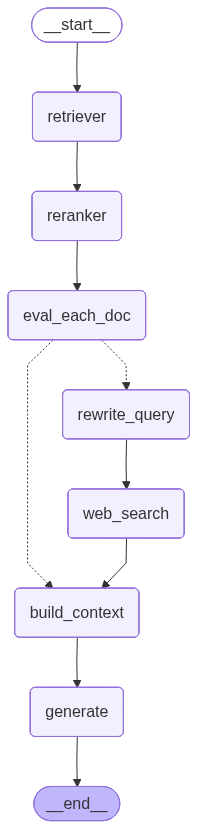

In [133]:
graph=StateGraph(State)
graph.add_node("retriever", retrieve_node)
graph.add_node("reranker", rerank_documents)
graph.add_node("eval_each_doc", eval_each_doc)
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("web_search", web_search)
graph.add_node("build_context", build_context)
graph.add_node("generate", generate)

graph.add_edge(START, "retriever")

graph.add_edge("retriever", "reranker")
graph.add_edge("reranker", "eval_each_doc")
graph.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "build_context": "build_context",
        "rewrite_query": "rewrite_query",
    },
)
graph.add_edge("build_context", "generate")
graph.add_edge("rewrite_query", "web_search")
graph.add_edge("web_search", "build_context")
graph.add_edge("build_context", "generate")
graph.add_edge("generate", END)
app = graph.compile()
app

In [134]:
result=app.invoke({"question": "What is the topic of the paper?"})

Reranking documents...
Top documents: 3
VERDICT: AMBIGUOUS
entering web search
exiting web search
building context...
entering generate
exiting generate


In [135]:
result

{'question': 'What is the topic of the paper?',
 'verdict': 'AMBIGUOUS',
 'docs': [Document(id='3fb49062-065e-4503-a983-93aff3c2618a', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'Elsevier', 'creationdate': '2015-11-13T12:06:46+00:00', 'author': '', 'crossmarkdomains[1]': 'sciencedirect.com', 'crossmarkdomains[2]': 'elsevier.com', 'crossmarkdomainexclusive': 'true', 'crossmarkmajorversiondate': '2010-04-23', 'elsevierwebpdfspecifications': '6.4', 'keywords': '', 'moddate': '2015-11-13T14:42:35+05:30', 'subject': 'Applied Soft Computing Journal, 37 (2015) 332-344. doi:10.1016/j.asoc.2015.08.033', 'title': 'Enhancement of low quality underwater image through integrated global and local contrast correction', 'doi': '10.1016/j.asoc.2015.08.033', 'robots': 'noindex', 'source': 'C:\\Projects\\rag_project\\Methodology_Paper.pdf', 'total_pages': 13, 'page': 2, 'page_label': '3'}, page_content='and detailed in subsequent sections.\n3. Motivation\nThe studies conducted by Iqbal et a

In [102]:
answer = result["answer"]
print("FINAL ANSWER:", answer)

FINAL ANSWER:  Based on the context provided, the topic of the paper appears to be related to image processing or computer graphics, specifically the generation of branch images and their corresponding 3D RGB color models using current state-of-the-art techniques.


In [137]:
result2=app.invoke({"question": "What is the abstract of paper?"})

Reranking documents...
Top documents: 3
VERDICT: INCORRECT
entering web search
exiting web search
building context...
entering generate
exiting generate


In [138]:
result2

{'question': 'What is the abstract of paper?',
 'verdict': 'INCORRECT',
 'docs': [Document(id='3161478a-a3c6-4bd9-99a1-929a58c1cb41', metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'Elsevier', 'creationdate': '2015-11-13T12:06:46+00:00', 'author': '', 'crossmarkdomains[1]': 'sciencedirect.com', 'crossmarkdomains[2]': 'elsevier.com', 'crossmarkdomainexclusive': 'true', 'crossmarkmajorversiondate': '2010-04-23', 'elsevierwebpdfspecifications': '6.4', 'keywords': '', 'moddate': '2015-11-13T14:42:35+05:30', 'subject': 'Applied Soft Computing Journal, 37 (2015) 332-344. doi:10.1016/j.asoc.2015.08.033', 'title': 'Enhancement of low quality underwater image through integrated global and local contrast correction', 'doi': '10.1016/j.asoc.2015.08.033', 'robots': 'noindex', 'source': 'C:\\Projects\\rag_project\\Methodology_Paper.pdf', 'total_pages': 13, 'page': 12, 'page_label': '13'}, page_content='interpolation,\nexcessed on September 2013.\n[22] Image Analysis, Programming in Java A